# Jupyter Notebook for the Fisher analysis
## Creates Figs. 2 and 3 of the letter

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.colors as colors
import astropy.units as u
from astropy.coordinates import SkyCoord
plt.rcParams['text.usetex'] = True
plt.rc('font', family = 'roman')
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [2]:
# Define TESS observational parameters used in the Fisher sensitivity estimate

# Cadence values of FFIs:
# 30 min (Sectors 1-26), 10 min (Sectors 27-55), and 200 s (Sector 56 onward)
cadence = np.array([30*60, 10*60, 200])

# Typical duration of one TESS sector (two spacecraft orbits) in sec
T = 27.4 * 24 * 3600

# Convert conservative single-star and per-cadence astrometric precision from pixels to radians
# Assumption: 0.01 pixel precision with TESS pixel scale of 21 arcsec/pixel
sigma = 0.01 * 21 * np.pi / (180 * 3600)

# Speed of light in vacuum (m/s)
c = 2.99792458*1e8

# Prefactor of the Fisher matrix scaling for constant acceleration sensitivity
alpha_array = T**3 / (12 * cadence * sigma**2 * c**2)

In [3]:
# For the ecliptic pole regions:

# Number of TESS sectors in the continuous viewing zones (CVZs) for each cadence
# SEP: 30 min, 10 min, 200 s cadence
n_sectors_SEP = [13, 13, 17]

# NEP: 30 min, 10 min, 200 s cadence
n_sectors_NEP = [13, 11, 19]


# Construct observation times for multiple TESS sectors with different cadences
def build_sector_times(n_sectors, cadence, t_start=0.0):
    t_list = []
    t = t_start

    # Generate time samples for each consecutive sector
    for _ in range(n_sectors):

        # Number of observations within one sector
        n_steps = int(T // cadence)+1

        # Generate time array for current sector
        t_sector = t + np.arange(n_steps) * cadence
        t_list.append(t_sector)

        # Start next sector after the end of the current one
        t = t_sector[-1] + cadence

    return np.concatenate(t_list)


# Generate observation times for SEP and NEP CVZs for each cadence regime
t1_SEP = build_sector_times(n_sectors_SEP[0], cadence[0], t_start=0.0)
t2_SEP = build_sector_times(n_sectors_SEP[1], cadence[1], t_start=t1_SEP[-1]+cadence[1])
t3_SEP = build_sector_times(n_sectors_SEP[2], cadence[2], t_start=t2_SEP[-1]+cadence[2])

t1_NEP = build_sector_times(n_sectors_NEP[0], cadence[0], t_start=0.0)
t2_NEP = build_sector_times(n_sectors_NEP[1], cadence[1], t_start=t1_NEP[-1]+cadence[1])
t3_NEP = build_sector_times(n_sectors_NEP[2], cadence[2], t_start=t2_NEP[-1]+cadence[2])


# Combine all cadence regimes and center observation times around the mean epoch
t_k_SEP = np.concatenate([t1_SEP, t2_SEP, t3_SEP])
t_k_SEP = t_k_SEP - np.mean(t_k_SEP)

t_k_NEP = np.concatenate([t1_NEP, t2_NEP, t3_NEP])
t_k_NEP = t_k_NEP - np.mean(t_k_NEP)


# Verify that sum_k t_k \approx 0 (= assumption in our Fisher analysis) or at least (sum_k t_k)^2 << sum_k t_k^2
print("$\sum_k t_k = 0$ ?")
print("SEP:", np.sum(t_k_SEP))
print("NEP:", np.sum(t_k_NEP))
print("$(\sum_k t_k)^2 / \sum_k t_k^2 << 1$ ?")
print("SEP:", np.sum(t_k_SEP)**2/np.sum(t_k_SEP**2))
print("NEP:", np.sum(t_k_NEP)**2/np.sum(t_k_NEP**2))


# Compute temporal Fisher prefactor for the polar CVZ observations
alpha_poles = np.array([np.sum(t_k_SEP**2), np.sum(t_k_NEP**2)])/(sigma**2*c**2)

$\sum_k t_k = 0$ ?
SEP: 0.001495361328125
NEP: 0.000946044921875
$(\sum_k t_k)^2 / \sum_k t_k^2 << 1$ ?
SEP: 1.5966761121385606e-26
NEP: 6.30031312896247e-27


In [4]:
# Define TESS sector range used for the Fisher analysis
sec_min = 1
sec_max = 96
sectors = np.arange(sec_min, sec_max + 1)

# Initialize arrays for acceleration sensitivity estimates
# Cartesian acceleration components
sigma_ax = []
sigma_ay = []
sigma_az = []

# Cartesian acceleration components for the CVZs
sigma_ax_poles = []
sigma_ay_poles = []
sigma_az_poles = []
sigma_a_vec_poles = []

# Minimum acceleration sensitivity optimized over sky direction (RA/Dec)
sigma_a_RA_Dec_min = []

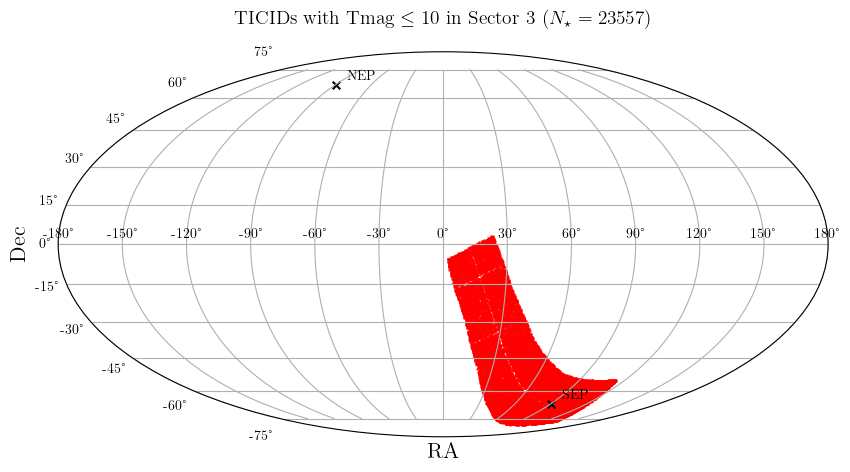

In [5]:
# Example visualization of TIC stars with Tmag <= 10 for a selected sector

# Select a TESS sector and load the corresponding TIC star catalog
sector_number_test = 3

# Load TIC stars assigned to the selected sector
# df_test = pd.read_csv(f"tic/TIC_common_all_sectors_SEP.csv")
df_test = pd.read_csv(f"tic/TICIDs_sector_{sector_number_test}.csv")

# Extract sky coordinates
ra_test = df_test["ra"].to_numpy()
dec_test = df_test["dec"].to_numpy()

# Convert coordinates from degrees to radians for Mollweide projection
ra_rad_test = np.deg2rad(ra_test)
dec_rad_test = np.deg2rad(dec_test)

# Shift right ascension range from [0, 2pi] to [-pi, pi] for plotting
ra_rad_test_shifted = np.remainder(ra_rad_test + 2*np.pi, 2*np.pi)
ra_rad_test_shifted[ra_rad_test_shifted > np.pi] -= 2*np.pi


# Plot sky distribution of selected TIC stars
fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(111, projection="mollweide")

ax.scatter(
    ra_rad_test_shifted,
    dec_rad_test,
    color="red",
    s=1,
    alpha=0.6
)


# Mark northern and southern ecliptic poles
NEP = np.deg2rad(np.array([-90, 66.56]))
SEP = -NEP

ax.scatter(NEP[0], NEP[1], color="black", s=30, marker="x")
ax.text(NEP[0]+0.05, NEP[1]+0.05, "NEP", fontweight="bold")

ax.scatter(SEP[0], SEP[1], color="black", s=30, marker="x")
ax.text(SEP[0]+0.05, SEP[1]+0.05, "SEP", fontweight="bold")


# Set right ascension tick labels in degrees
tick_deg = np.arange(-180, 181, 30)
tick_rad = np.deg2rad(tick_deg)

ax.set_xticks(tick_rad)
ax.set_xticklabels([f"{d}°" for d in tick_deg])

ax.set_xlabel("RA", fontsize=16)
ax.set_ylabel("Dec", fontsize=16)

ax.grid(True)

# Display number of selected TIC stars in the sector
plt.title(
    rf"TICIDs with $\mathrm{{Tmag}} \leq 10$ in Sector {sector_number_test} "
    rf"($N_\star = {len(df_test)}$)",
    fontsize=14,
    y=1.05
)

plt.show()

In [6]:
def fisher_geometry(n, rotation, shift):
    """
    Compute the geometric Fisher matrix for acceleration sensitivity estimates,
    including optional marginalization over FOV rotation and translation
    nuisance parameters. 
    n denotes the line of sights for all stars considered.
    """

    # Number of stars
    S = n.shape[0]

    # Basic Fisher geometry without nuisance parameters
    outer = np.einsum('si,sj->ij', n, n)
    M = S * np.eye(3) - outer

    # Return the standard Fisher geometry if no nuisance parameters are included
    if not rotation and not shift:
        return M

    # Initialize matrices for rotation and translation nuisance parameters
    D = np.zeros((3, 3))
    Nsum = np.zeros((3, 3))

    # Construct contributions from all observed stellar directions
    for n_i in n:

        # Cross-product matrix representing infinitesimal FOV rotations
        Nx = np.array([
            [0,       -n_i[2],  n_i[1]],
            [n_i[2],   0,      -n_i[0]],
            [-n_i[1],  n_i[0],  0]
        ])

        # Projection operator onto the tangent plane of the sky
        P_i = np.eye(3) - np.outer(n_i, n_i)

        # Accumulate rotation coupling and translation terms
        D += P_i @ Nx
        Nsum += Nx

    # --------------------------------------------------
    # Marginalize over FOV rotation only
    # G = M - D M^{-1} D^T
    # --------------------------------------------------
    if rotation and not shift:

        M_inv = np.linalg.inv(M)

        G = M - D @ M_inv @ D.T

        return G

    # --------------------------------------------------
    # Marginalize over both FOV rotation and translation
    # using the full Schur complement
    # --------------------------------------------------
    if rotation and shift:

        # Fisher matrix of the combined acceleration and nuisance parameters
        Q = np.block([
            [M,        Nsum],
            [Nsum.T,   S*np.eye(3)]
        ])

        Q_inv = np.linalg.inv(Q)

        # Coupling between acceleration and nuisance parameters
        A = np.hstack([-D, M])

        # Effective Fisher matrix after marginalizing nuisance parameters
        G = M - A @ Q_inv @ A.T

        return G

In [7]:
# Compute Fisher acceleration sensitivities for each TESS sector
n_stars = []

for sector_number in sectors:

    # Load positions of all TIC stars with Tmag <= 10 in the current sector
    df = pd.read_csv(f"tic/TICIDs_sector_{sector_number}.csv")

    # Extract equatorial coordinates
    ra = df["ra"].to_numpy()
    dec = df["dec"].to_numpy()

    # Transform sky coordinates to ICRS and convert to Cartesian unit vectors
    coords_icrs = SkyCoord(
        ra=ra*u.deg,
        dec=dec*u.deg,
        frame="fk5",
        equinox="J2000"
    ).transform_to("icrs")

    n_all_stars_sec_icrs = coords_icrs.cartesian.xyz.value.T
    
    # Unit vectors pointing toward all observed stars
    n = n_all_stars_sec_icrs

    # Number of stars contributing to the Fisher matrix
    S = n.shape[0]

    # Compute geometric Fisher matrix including FOV rotation and translation nuisance parameters
    G = fisher_geometry(n, rotation=True, shift=True)

    # Select cadence-dependent Fisher prefactor according to the TESS mission phase
    if 1 <= sector_number <= 26:
        alpha = alpha_array[0]
    elif 27 <= sector_number <= 55:
        alpha = alpha_array[1]
    elif sector_number >= 56:
        alpha = alpha_array[2]

    # Construct acceleration Fisher matrix and covariance matrix
    F_aa_sec = alpha * G
    C_sec = np.linalg.inv(F_aa_sec)

    # Define sky grid for evaluating directional acceleration sensitivity
    Nra_ = 360 + 1
    Ndec_ = 180 + 1

    ra_sky_ = np.linspace(0, 360, Nra_)
    dec_sky_ = np.linspace(-90, 90, Ndec_)

    RA_sky_, DEC_sky_ = np.meshgrid(ra_sky_, dec_sky_)

    sigma_a_map_sec = np.zeros_like(RA_sky_)

    # Evaluate projected acceleration uncertainty for all sky directions
    for i in range(Ndec_):
        for j in range(Nra_):

            a_ = np.deg2rad(RA_sky_[i,j])
            d_ = np.deg2rad(DEC_sky_[i,j])

            u_vec_ = np.array([
                np.cos(d_)*np.cos(a_),
                np.cos(d_)*np.sin(a_),
                np.sin(d_)
            ])

            sigma_a_map_sec[i,j] = np.sqrt(u_vec_ @ C_sec @ u_vec_)

    # Store best directional sensitivity and Cartesian acceleration uncertainties
    sigma_a_RA_Dec_min.append(np.min(sigma_a_map_sec))

    sigma_a_vec = np.sqrt(np.diag(C_sec))

    sigma_ax.append(sigma_a_vec[0])
    sigma_ay.append(sigma_a_vec[1])
    sigma_az.append(sigma_a_vec[2])

    # Store number of stars in the sector
    n_stars.append(S)

    print(f"\r{sector_number}/{sec_max}", end="", flush=True)

96/96

In [8]:
# Compute Fisher acceleration sensitivities for stars in the TESS CVZs
n_stars_poles = []

# Analyze southern and northern ecliptic pole samples separately
poles = ["SEP", "NEP"]

for idx, pole in zip([0, 1], poles):

    # Load TIC stars with Tmag <= 10 of CVZs
    df = pd.read_csv(f"tic/TIC_common_all_sectors_{pole}.csv")

    # Extract equatorial sky coordinates
    ra = df["ra"].to_numpy()
    dec = df["dec"].to_numpy()

    # Transform coordinates to ICRS and convert to Cartesian unit vectors
    coords_icrs = SkyCoord(
        ra=ra*u.deg,
        dec=dec*u.deg,
        frame="fk5",
        equinox="J2000"
    ).transform_to("icrs")

    n_all_stars_sec_icrs = coords_icrs.cartesian.xyz.value.T

    # Unit vectors pointing toward all stars in the CVZ sample
    n = n_all_stars_sec_icrs

    # Number of stars contributing to the Fisher matrix
    S = n.shape[0]

    # Compute geometric Fisher matrix including FOV rotation and translation nuisance parameters
    G = fisher_geometry(n, rotation=True, shift=True)

    # Compute marginalized acceleration uncertainties for the CVZ sample
    sigma_a_vec = np.sqrt(np.diag(np.linalg.inv(G)) / alpha_poles[idx])
    sigma_a_vec_poles.append(sigma_a_vec)

    # Store Cartesian acceleration sensitivities
    sigma_ax_poles.append(sigma_a_vec[0])
    sigma_ay_poles.append(sigma_a_vec[1])
    sigma_az_poles.append(sigma_a_vec[2])

    # Store number of continuously observed stars
    n_stars_poles.append(S)

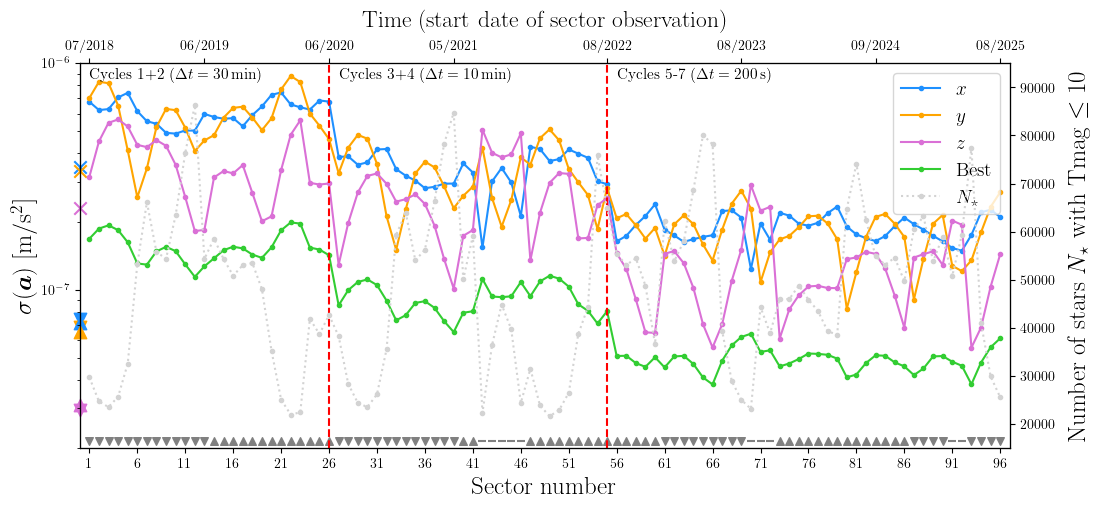

In [14]:
# Plot acceleration sensitivity per TESS sector and the corresponding number of observed stars

fig, ax1 = plt.subplots(figsize=(12,5))

# Plot Cartesian and best-direction acceleration sensitivities
colors = ["dodgerblue", "orange", "orchid", "limegreen"]
ax1.plot(sectors, sigma_ax, label=r'$x$', marker='o', markersize=3, color=colors[0])
ax1.plot(sectors, sigma_ay, label=r'$y$', marker='o', markersize=3, color=colors[1])
ax1.plot(sectors, sigma_az, label=r'$z$', marker='o', markersize=3, color=colors[2])
ax1.plot(sectors, sigma_a_RA_Dec_min, label=r'Best', marker='o', markersize=3, color=colors[3])

# Configure axis
ax1.set_xlabel("Sector number", fontsize=18)
ax1.set_ylabel(r"$\sigma(\boldsymbol{a})$ [$\mathrm{m/s^2}$]", fontsize=18)
ax1.set_yscale("log")
ax1.set_xlim(sec_min-1, sec_max+1)
ax1.set_ylim(2e-8, 1e-6)
ax1.set_xticks(np.array(sectors)[::5])

# Add observation dates as a secondary x-axis
ax_top = ax1.twiny()
ax_top.set_xlim(ax1.get_xlim())

sector_dates = {
    1: "07/2018",
    13: "06/2019",
    26: "06/2020",
    39: "05/2021",
    55: "08/2022",
    69: "08/2023",
    83: "09/2024",
    96: "08/2025",
}

ax_top.set_xticks(list(sector_dates.keys()))
ax_top.set_xticklabels(list(sector_dates.values()))
ax_top.set_xlabel("Time (start date of sector observation)", fontsize=17, labelpad=9)
ax_top.tick_params(axis='x', labelsize=10)

# Add number of observed stars on secondary y-axis
ax2 = ax1.twinx()

ax2.plot(
    sectors,
    np.array(n_stars),
    color='lightgray',
    label=r'$N_\star$',
    linestyle="dotted",
    marker="o",
    markersize=3
)

ax2.set_ylabel(
    "Number of stars $N_\star$ with $\mathrm{Tmag} \leq 10$",
    fontsize=18,
    labelpad=10
)
ax2.set_ylim(1.5e4, 9.5e4)

# Mark changes between TESS observing cycles/cadences
ax1.axvline(x=26, color='red', linestyle='--')
ax1.axvline(x=55, color='red', linestyle='--')

# Add mean sensitivity values
xmin = ax1.get_xlim()[0]
mean_val = np.array([np.mean(sigma_ax), np.mean(sigma_ay), np.mean(sigma_az)])

for y, c in zip(mean_val, colors):
    ax1.scatter(xmin, y, marker='x', s=80, color=c, clip_on=False)

#####################################################################################################
# Add CVZ pole sensitivities as markers

trans_y = transforms.blended_transform_factory(ax1.transAxes, ax1.transData)

x_left = 0
sigma_components = np.array(sigma_a_vec_poles)

# SEP and NEP sensitivities
for i, comp in enumerate(sigma_components[0]):
    ax1.scatter(x_left, comp, marker="v", color=colors[i], transform=trans_y, s=80, clip_on=False)

for i, comp in enumerate(sigma_components[1]):
    ax1.scatter(x_left, comp, marker="^", color=colors[i], transform=trans_y, s=80, clip_on=False)

# Mark sectors contributing to SEP, NEP, and ecliptic coverage

trans_x = transforms.blended_transform_factory(ax1.transData, ax1.transAxes)
y_bottom = 0.02

intervals_SEP = [(1,13), (27,39), (61,69), (87,90), (93,96)]
intervals_NEP = [(14,26), (40,41), (47,55), (56,60), (73,83), (84,86)]
intervals_ecliptic = [(42,46), (70,72), (91,92)]

for x0, x1 in intervals_SEP:
    xs = np.arange(x0, x1 + 1)
    ax1.scatter(xs, np.full_like(xs, y_bottom, dtype=float), marker="v", color="gray", transform=trans_x, clip_on=False, s=30)

for x0, x1 in intervals_NEP:
    xs = np.arange(x0, x1 + 1)
    ax1.scatter(xs, np.full_like(xs, y_bottom, dtype=float), marker="^", color="gray", transform=trans_x, clip_on=False, s=30)

for x0, x1 in intervals_ecliptic:
    xs = np.arange(x0, x1 + 1)
    ax1.scatter(xs, np.full_like(xs, y_bottom, dtype=float), marker="_", color="gray", transform=trans_x, clip_on=False, s=30)

#####################################################################################################

# Indicate TESS observing cycles and cadences
ax1.text(1, 8.5e-7, "Cycles 1+2 ($\Delta t = 30\,\mathrm{min}$)", color="black", fontsize=11)
ax1.text(27, 8.5e-7, "Cycles 3+4 ($\Delta t = 10\,\mathrm{min}$)", color="black", fontsize=11)
ax1.text(56, 8.5e-7, "Cycles 5-7 ($\Delta t = 200\,\mathrm{s}$)", color="black", fontsize=11)

# Combine legends from both y-axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=14,
    loc="upper right"
)
plt.show()

In [22]:
# Compute directional acceleration sensitivity map for a selected TESS CVZ pole sample

import astropy.units as u

# Select CVZ pole sample (SEP or NEP) and load stars
label_pole = "NEP"
df_pole = pd.read_csv(f"tic/TIC_common_all_sectors_{label_pole}.csv")

# Extract stellar sky coordinates
ra_pole = df_pole["ra"].to_numpy()
dec_pole = df_pole["dec"].to_numpy()

# Transform coordinates to ICRS and convert to Cartesian unit vectors
coords_icrs_pole = SkyCoord(
    ra=ra_pole*u.deg,
    dec=dec_pole*u.deg,
    frame="fk5",
    equinox="J2000"
).transform_to("icrs")

n_pole = coords_icrs_pole.cartesian.xyz.value.T

# Include marginalization over FOV rotation and translation nuisance parameters
rotation = True
shift = True

# Compute geometric Fisher matrix of the pole stellar distribution
G_pole = fisher_geometry(n_pole, rotation=rotation, shift=shift)

# Select temporal Fisher prefactor corresponding to the selected pole
if label_pole == "SEP":
    alpha_poles_val = alpha_poles[0]
elif label_pole == "NEP":
    alpha_poles_val = alpha_poles[1]

# Construct acceleration covariance matrix
F_aa_pole = alpha_poles_val * G_pole
C_pole = np.linalg.inv(F_aa_pole)

# Define high-resolution sky grid for directional sensitivity evaluation
Nra = 3600 + 1
Ndec = 1800 + 1

ra_sky = np.linspace(0, 360, Nra)
dec_sky = np.linspace(-90, 90, Ndec)

RA_sky, DEC_sky = np.meshgrid(ra_sky, dec_sky)

sigma_map = np.zeros_like(RA_sky)

# Evaluate projected acceleration uncertainty for each sky direction
for i in range(Ndec):
    for j in range(Nra):

        a = np.deg2rad(RA_sky[i,j])
        d = np.deg2rad(DEC_sky[i,j])

        # Unit vector of the tested acceleration direction
        u_vec = np.array([
            np.cos(d)*np.cos(a),
            np.cos(d)*np.sin(a),
            np.sin(d)
        ])

        sigma_map[i,j] = np.sqrt(u_vec @ C_pole @ u_vec)

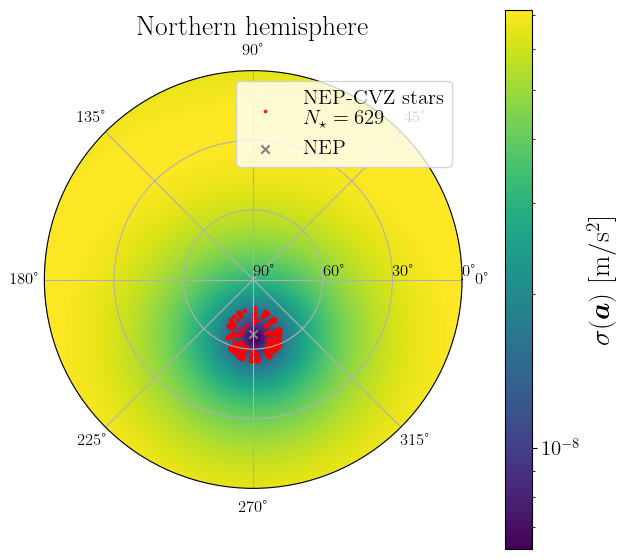

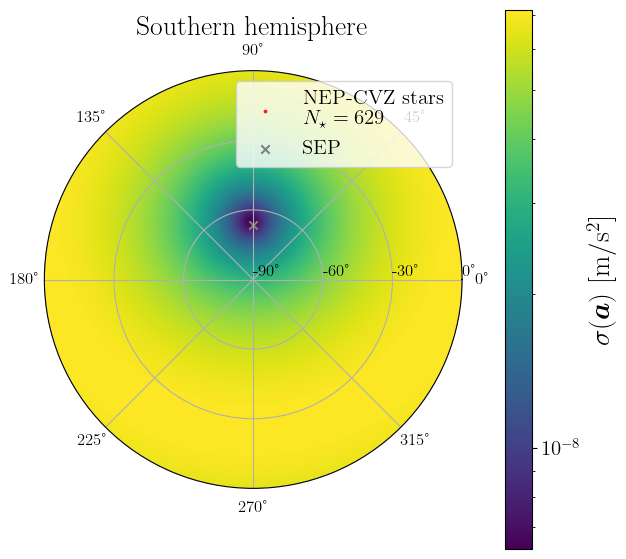

In [23]:
import matplotlib.colors as colors

# ============================================================
# Northern hemisphere
# ============================================================

# Select number of CVZ stars for the corresponding pole sample
N_star_poles = n_stars_poles[0] if label_pole == "SEP" else n_stars_poles[1]

# Plot directional acceleration sensitivity in polar sky coordinates
fig, ax = plt.subplots(figsize=(7,7), subplot_kw={"projection": "polar"})

# Mask the southern hemisphere and plot only northern sky directions
mask = DEC_sky >= 0

theta = np.deg2rad(RA_sky)
r = 90 - DEC_sky

# Display acceleration sensitivity map on a logarithmic scale
im = ax.pcolormesh(
    theta,
    r,
    np.where(mask, sigma_map, np.nan),
    shading="auto",
    norm=colors.LogNorm()
)

# Overlay CVZ stars
theta_pole = np.deg2rad(ra_pole)
r_pole = 90 - dec_pole

ax.scatter(
    theta_pole,
    r_pole,
    s=3,
    c="red",
    alpha=0.8,
    label=f"{label_pole}-CVZ stars"+f"\n"+rf"$N_\star = {N_star_poles}$"
)

# Mark ecliptic pole location
ax.scatter(
    np.deg2rad(270),
    90-66.65,
    marker="x",
    c="gray",
    label="NEP"
)

# Configure polar projection
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_rlim(0, 90)
ax.set_rlabel_position(0)
ax.set_rticks([0, 30, 60, 90])
ax.set_yticklabels(["90°", "60°", "30°", "0°"])

ax.set_title("Northern hemisphere", fontsize=20)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

# Add colorbar
cbar = plt.colorbar(im, pad=0.08)
cbar.set_label(r"$\sigma(\boldsymbol{a})$ [$\mathrm{m/s^2}$]", fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax.legend(loc="upper right", fontsize=15)

plt.show()


# ============================================================
# Southern hemisphere
# ============================================================

# Plot directional acceleration sensitivity in the southern sky
fig, ax = plt.subplots(figsize=(7,7), subplot_kw={"projection": "polar"})

# Mask the northern hemisphere and plot only southern sky directions
mask = DEC_sky <= 0

theta = np.deg2rad(RA_sky)
r = 90 + DEC_sky

# Display acceleration sensitivity map on a logarithmic scale
im = ax.pcolormesh(
    theta,
    r,
    np.where(mask, sigma_map, np.nan),
    shading="auto",
    norm=colors.LogNorm()
)

# Overlay CVZ stars
theta_pole = np.deg2rad(ra_pole)
r_pole = 90 + dec_pole

ax.scatter(
    theta_pole,
    r_pole,
    s=3,
    c="red",
    alpha=0.8,
    label=f"{label_pole}-CVZ stars"+f"\n"+rf"$N_\star = {N_star_poles}$"
)

# Mark ecliptic pole location
ax.scatter(
    np.deg2rad(90),
    90-66.65,
    marker="x",
    c="gray",
    label="SEP"
)

# Configure polar projection
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_rlim(0, 90)
ax.set_rlabel_position(0)
ax.set_rticks([0, 30, 60, 90])
ax.set_yticklabels(["-90°", "-60°", "-30°", "0°"])

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_title("Southern hemisphere", fontsize=20)

# Add colorbar
cbar = plt.colorbar(im, pad=0.08)
cbar.set_label(r"$\sigma(\boldsymbol{a})$ [$\mathrm{m/s^2}$]", fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax.legend(loc="upper right", fontsize=15)

plt.show()

In [25]:
# Find minimum acceleration sensitivity in the selected hemisphere

# Define hemisphere mask
if label_pole == "SEP":
    mask_dec = DEC_sky <= 0
elif label_pole == "NEP":
    mask_dec = DEC_sky >= 0

sigma_map_masked = np.where(mask_dec, sigma_map, np.nan)

# Determine minimum value and corresponding index
min_value = np.nanmin(sigma_map_masked)
min_index = np.unravel_index(np.nanargmin(sigma_map_masked), sigma_map.shape)

print(min_value)

# Convert grid index to sky coordinates
i, j = min_index

print("RA  =", RA_sky[i, j])
print("Dec =", DEC_sky[i, j])

6.340504616017404e-09
RA  = 272.2
Dec = 64.9
